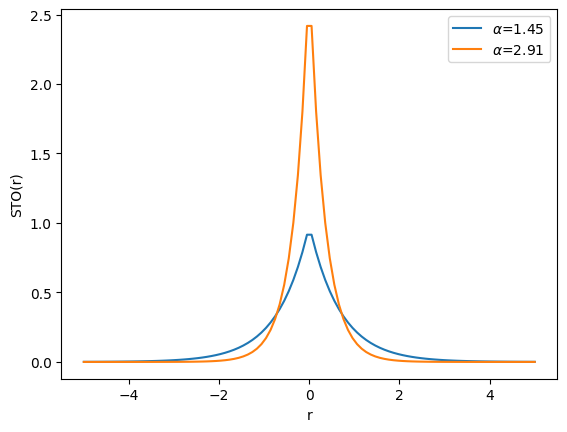

In [2]:
from math import *
import numpy as np
import matplotlib.pyplot as plt

# Slater function
def Slater(r, alpha):        
    return np.sqrt(alpha**3/np.pi) * np.exp(-alpha * r)

# range for r
x = np.linspace(-5, 5, 100)
r = abs(x)

# alpha 
alpha = [1.45, 2.91]

# plot the Slater functions
for i, alp in enumerate(alpha):
    plt.plot(x, Slater(r, alp), label=rf'$\alpha$={alp}')

plt.xlabel("r")
plt.ylabel("STO(r)")
plt.legend()
plt.show()


In [3]:
def Spq(alpha_p, alpha_q):
    return (2 * np.sqrt(alpha_p*alpha_q) / (alpha_p+alpha_q)) ** 3

def Ipq(alpha_p, alpha_q):
    return 4 * (np.sqrt(alpha_p*alpha_q) / (alpha_p + alpha_q)) ** 3 * (alpha_p*alpha_q - 2 * (alpha_p+alpha_q))

def pq_rs(alpha_p, alpha_q, alpha_r, alpha_s):
    return 32*(alpha_p*alpha_q*alpha_r*alpha_s)**1.5*( 1/((alpha_p+alpha_q)**3*(alpha_r+alpha_s)**2)\
                                                     - 1/((alpha_p+alpha_q)**3*(alpha_p + alpha_q + alpha_r+alpha_s)**2)\
                                                     - 1/((alpha_p+alpha_q)**2*(alpha_p + alpha_q + alpha_r+alpha_s)**3))

In [4]:
n = 2
alpha = [1.45, 2.91]

Sij = np.zeros((n, n))
Iij = np.zeros((n, n))
Jijkl = np.zeros((n,n,n,n))
for i in range(n):
    for j in range(n):
        Sij[i, j] = Spq(alpha[i], alpha[j])
        Iij[i, j] = Ipq(alpha[i], alpha[j])
        for k in range(n):
            for l in range(n):
                Jijkl[i, j, k, l] = pq_rs(alpha[i], alpha[j], alpha[k], alpha[l])

print("Sij = \n", Sij)
print("Iij = \n", Iij)
print("Jijkl = \n", Jijkl)


Sij = 
 [[1.         0.83660799]
 [0.83660799 1.        ]]
Iij = 
 [[-1.84875    -1.88257712]
 [-1.88257712 -1.58595   ]]
Jijkl = 
 [[[[0.90625    0.90328097]
   [0.90328097 1.1825892 ]]

  [[0.90328097 0.95363136]
   [0.95363136 1.29799628]]]


 [[[0.90328097 0.95363136]
   [0.95363136 1.29799628]]

  [[1.1825892  1.29799628]
   [1.29799628 1.81875   ]]]]


In [5]:
n= 2
C = np.zeros((n))   
C[0] = 1
C[1] = 0
#print(C)
def compute_F(C): 
    Fij =np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            Fij[i,j] = Iij[i,j]
            for k in range(n):
                for l in range(n):
                    Fij[i,j] += C[k]*C[l]*Jijkl[i, j, k, l]
    return Fij
Fij = compute_F(C)
print("Fij = \n", Fij)

Fij = 
 [[-0.9425     -0.97929615]
 [-0.97929615 -0.4033608 ]]


In [6]:
# Energy
def compute_energy(C, Fij):
    Energy_I = 0.
    Energy_J = 0.
    Energy = 0.
    for i in range(n):
        for j in range(n):
            Energy_I += C[i]*C[j]*Iij[i, j]
            Energy_J += C[i]*C[j]*Fij[i, j]
    Energy = Energy_I + Energy_J
    return Energy
E0 = compute_energy(C, Fij)
print("E_HF =", E0*27.2114, 'ev')

E_HF = -75.95382024999999 ev


In [7]:
# SD
def compute_new_C(Fij, prnt=False):
    eigval, eigvec = np.linalg.eig(Sij)
    SD = np.diag(eigval)
    SD_inv_sqrt = np.diag(1 / np.sqrt(np.diag(SD)))
    P = eigvec
    P_inv = np.linalg.inv(P)

    S_inv_sqrt = np.dot(np.dot(P, SD_inv_sqrt), P_inv)

    #S_sqrt = np.linalg.inv(S_inv_sqrt)

    
    F_prime = np.dot(np.dot(S_inv_sqrt, Fij), S_inv_sqrt)
    

    epsilon, C_prime = np.linalg.eig(F_prime)

    # Find the index of the smallest eigenvalue
    min_index = np.argmin(epsilon)
    C_new = np.dot(S_inv_sqrt, C_prime[:, min_index])
    if prnt:
        print("S^-1/2 = \n", S_inv_sqrt)
        print("F' = \n", F_prime)
        print("C for the lowest eigenvalue = \n" ,C_new)
    return C_new

C_new = compute_new_C(Fij, True)
#F_new = compute_F(C_new)
#E_new = compute_energy(C_new, F_new)
#print("New E_HF =", E_new*27.2114, 'ev')

S^-1/2 = 
 [[ 1.60590209 -0.86801185]
 [-0.86801185  1.60590209]]
F' = 
 [[-0.00437938 -1.38732133]
 [-1.38732133  0.97980679]]
C for the lowest eigenvalue = 
 [-0.81090529 -0.21751009]


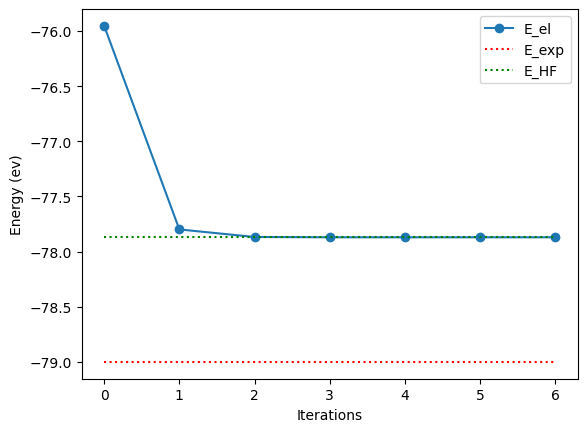

In [8]:
energy_array = []
# iterations 
#criteria = np.abs(E_new*27.2114 - E0*27.2114)
criteria = 1
#print(criteria)
it = 0
while(criteria >= 1e-8):
    
    if it == 0:
        C_old = np.array([1., 0.]) 
    else:
        C_old = np.copy(C)
    F_old = compute_F(C_old)
    E_old = compute_energy(C_old, F_old)
    energy_array.append(E_old*27.2114)

    C = compute_new_C(F_old)
    F_new = compute_F(C)
    E_new = compute_energy(C, F_new)

    criteria = np.abs(E_new*27.2114 - E_old*27.2114)
    it += 1
    #print(f"{it}")

#print(f"Iterations for convergence {it}")
#print(f"energy {E_new*27.2114}")
#print(energy_array)

plt.plot(range(it), energy_array, "o-", label ="E_el")
plt.hlines(y=-79,xmin=0, xmax=6, label="E_exp", linestyles=":", colors="red") 
plt.hlines(y=-77.87,xmin=0, xmax=6, label="E_HF", linestyles=":", colors="green")
plt.xlabel("Iterations")
plt.ylabel("Energy (ev)")
plt.legend() 
plt.show()
    